In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "browser"

In [10]:
ref_data_x = pd.read_csv('cartesian_ref_x.csv')
ref_data_y = pd.read_csv('cartesian_ref_y.csv')
ref_data_z = pd.read_csv('cartesian_ref_z.csv')

ref_x = ref_data_x['x'].to_numpy()
ref_y = ref_data_y['y'].to_numpy()
ref_z = ref_data_z['z'].to_numpy()

xyz_ref = np.stack([ref_x, ref_y, ref_z], axis=1)

t_common = ref_data_x['time_s'].to_numpy()

/tmp/ipykernel_22655/1631717735.py:24: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



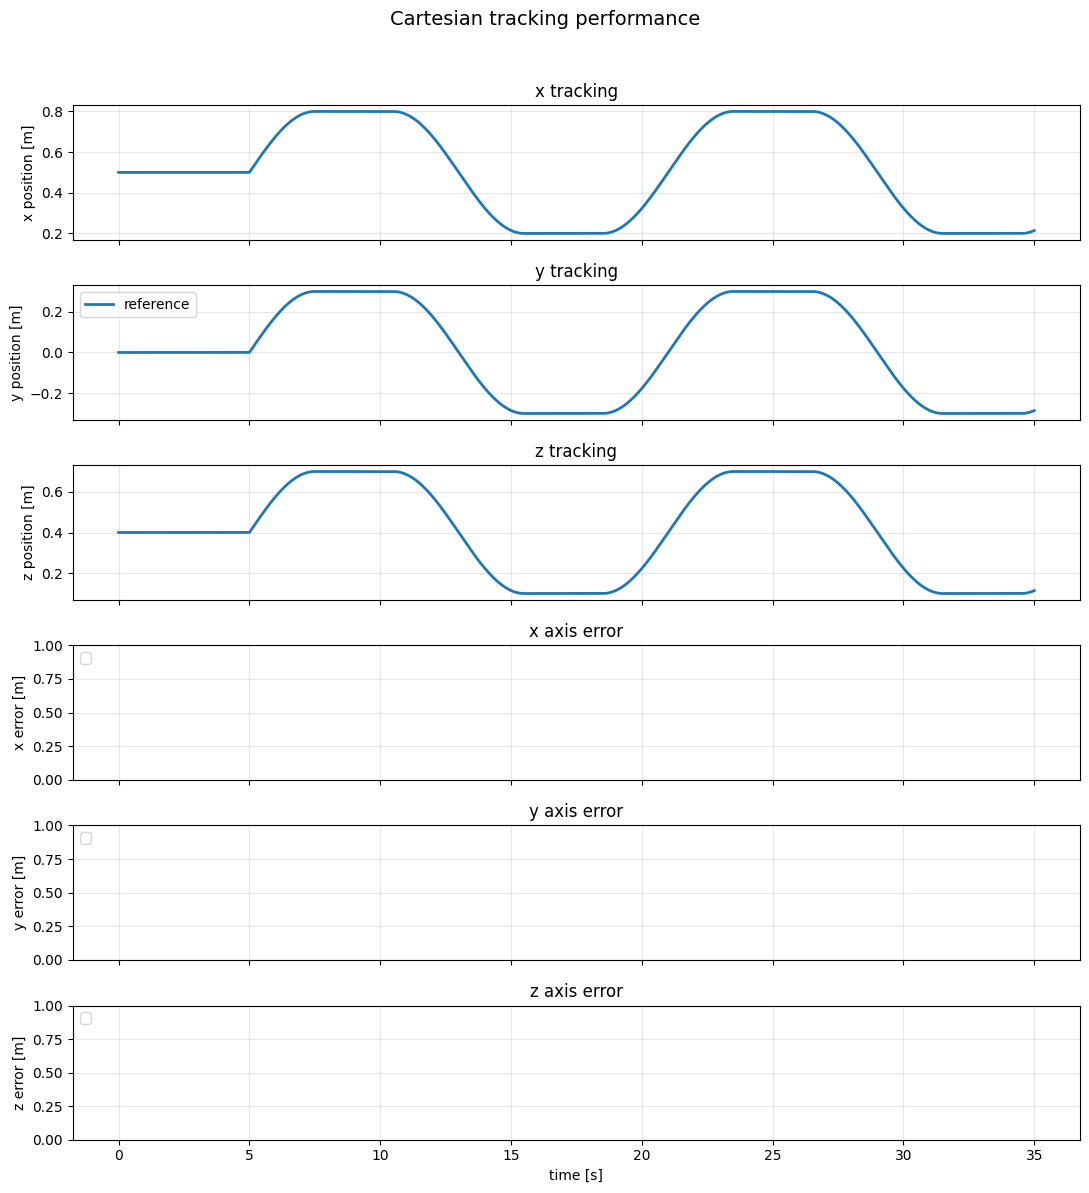

In [11]:
labels = ["x", "y", "z"]
units = "position [m]"

fig, axes = plt.subplots(6, 1, figsize=(11, 12), sharex=True)

# x, y, z tracking (axes 0,1,2)
for i, ax in enumerate(axes[:3]):
    ax.plot(t_common, xyz_ref[:, i], label="reference", linewidth=2)
    #ax.plot(t_common, xyz_data[:, i], label="without compensation", linewidth=1.5)
    # ax.plot(t_common, xyz_kernel[:, i], label="with compensation", linewidth=1.5)
    ax.set_ylabel(f"{labels[i]} {units}")
    ax.grid(True, alpha=0.3)
    ax.set_title(f"{labels[i]} tracking")

axes[1].legend(loc="upper left")

# x, y, z errors (axes 3,4,5)
for i, ax in enumerate(axes[3:6]):
    #ax.plot(t_common, err_no_comp_xyz[:, i], label="error without compensation", linewidth=1.5)
    #ax.plot(t_common, err_comp_xyz[:, i], label="error with compensation", linewidth=1.5)
    ax.set_ylabel(f"{labels[i]} error [m]")
    ax.grid(True, alpha=0.3)
    ax.set_title(f"{labels[i]} axis error")
    ax.legend(loc="upper left")

axes[-1].set_xlabel("time [s]")

fig.suptitle("Cartesian tracking performance", fontsize=14, y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()